# Stage 08 — Exploratory Data Analysis

Project dataset: `data/raw/card_tiers.csv` — one row per hobby-box card tier for the
2025-26 Topps NBA basketball line, merged with `product_line` / `release_date` from
`box_products.csv`. Reusable profiler: `src/eda.py` (`eda_summary`, `flag_columns`).

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy scipy pandas seaborn matplotlib

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

sns.set(context="talk", style="whitegrid")
pd.set_option("display.max_columns", 100)
sys.path.insert(0, str(Path.cwd()))

ct = pd.read_csv("data/raw/card_tiers.csv")
bp = pd.read_csv("data/raw/box_products.csv")[["product_id", "product_line", "release_date"]]
df = ct.merge(bp, on="product_id", how="left")
df["release_date"] = pd.to_datetime(df["release_date"])
print(df.shape)
df.head()

(194, 15)


,product_id,box_format,tier_name,tier_group,print_run,is_numbered,is_autograph,is_ssp,odds_pack,odds_box,est_value_usd,value_basis,source_note,product_line,release_date
0,2025-26-topps-chrome-bkb-hobby,Hobby,Base,base,NaN,False,False,False,NaN,NaN,0.5,rough_estimate_v0,NaN,2025-26 Topps Chrome Basketball,2025-12-18
1,2025-26-topps-chrome-bkb-hobby,Hobby,Base Refractor,parallel,NaN,False,False,False,3.0,0.15,3.0,rough_estimate_v0,NaN,2025-26 Topps Chrome Basketball,2025-12-18
2,2025-26-topps-chrome-bkb-hobby,Hobby,Prism Refractor,parallel,NaN,False,False,False,5.0,0.25,3.0,rough_estimate_v0,NaN,2025-26 Topps Chrome Basketball,2025-12-18
3,2025-26-topps-chrome-bkb-hobby,Hobby,Wave Refractor,parallel,NaN,False,False,False,14.0,0.70,3.0,rough_estimate_v0,NaN,2025-26 Topps Chrome Basketball,2025-12-18
4,2025-26-topps-chrome-bkb-hobby,Hobby,Negative Refractor,parallel,NaN,False,False,False,31.0,1.55,8.0,rough_estimate_v0,NaN,2025-26 Topps Chrome Basketball,2025-12-18


## 1) First look — structure & missingness

In [3]:
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   product_id     194 non-null    str           
 1   box_format     194 non-null    str           
 2   tier_name      194 non-null    str           
 3   tier_group     194 non-null    str           
 4   print_run      95 non-null     float64       
 5   is_numbered    194 non-null    bool          
 6   is_autograph   194 non-null    bool          
 7   is_ssp         194 non-null    bool          
 8   odds_pack      181 non-null    float64       
 9   odds_box       181 non-null    float64       
 10  est_value_usd  194 non-null    float64       
 11  value_basis    194 non-null    str           
 12  source_note    20 non-null     str           
 13  product_line   194 non-null    str           
 14  release_date   194 non-null    datetime64[us]
dtypes: bool(3), datetime64[us](1), flo

product_id         0
box_format         0
tier_name          0
tier_group         0
print_run         99
is_numbered        0
is_autograph       0
is_ssp             0
odds_pack         13
odds_box          13
est_value_usd      0
value_basis        0
source_note      174
product_line       0
release_date       0
dtype: int64

The NaNs are structural, not dirty: `print_run` NaN = unnumbered card (encoded by
`is_numbered`); `odds_pack` / `odds_box` NaN = only card-level odds published;
`source_note` is free-text on ~10% of rows.

## 2) Numeric profile

In [4]:
num = ["print_run", "odds_pack", "odds_box", "est_value_usd"]
prof = df[num].describe().T
prof["skew"] = [skew(df[c].dropna()) for c in prof.index]
prof["kurtosis"] = [kurtosis(df[c].dropna()) for c in prof.index]
prof

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
print_run,95.0,96.105263,106.471300,1.00,10.00,50.00,150.00,499.00,1.362879,1.640604
odds_pack,181.0,3519.198895,13156.920371,1.00,76.00,286.00,1209.00,138789.00,7.416351,65.578591
odds_box,181.0,189.061050,668.443559,0.05,3.95,16.65,71.38,6939.45,7.093851,60.980879
est_value_usd,194.0,287.324742,815.751158,0.50,16.00,100.00,150.00,5000.00,4.414497,18.452395


`odds_pack` (skew ~7.4), `odds_box` (~7.1), `est_value_usd` (~4.4) are extreme
right-skew — every downstream model needs `log10`. `print_run` is mildly skewed and
defined only for numbered cards.

## 2b) Categorical profile


=== box_format (1 distinct) ===
            count  prop
box_format             
Hobby         194   1.0

=== tier_group (5 distinct) ===
            count   prop
tier_group              
parallel      108  0.557
auto           47  0.242
insert         28  0.144
base            8  0.041
variation       3  0.015

=== is_numbered (2 distinct) ===
             count  prop
is_numbered             
False           99  0.51
True            95  0.49

=== is_autograph (2 distinct) ===
              count   prop
is_autograph              
False           147  0.758
True             47  0.242

=== is_ssp (2 distinct) ===
        count   prop
is_ssp              
False     186  0.959
True        8  0.041

=== value_basis (1 distinct) ===
                   count  prop
value_basis                   
rough_estimate_v0    194   1.0

=== product_line (6 distinct) ===
                                               count   prop
product_line                                               
2025-26 Topps C

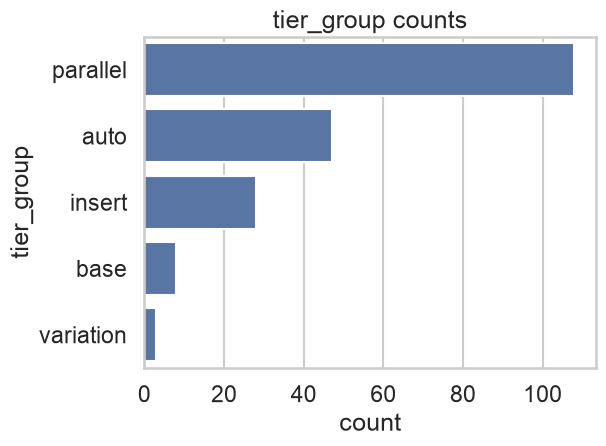

In [5]:
skip = {"tier_name", "source_note", "release_date", "product_id"}
cat_cols = [c for c in df.select_dtypes(exclude="number").columns if c not in skip]

for c in cat_cols:
    vc = df[c].value_counts(dropna=False)
    print(f"\n=== {c} ({df[c].nunique(dropna=False)} distinct) ===")
    print(pd.DataFrame({"count": vc, "prop": (vc / len(df)).round(3)}).head(8))

single = [c for c in cat_cols if df[c].nunique(dropna=False) == 1]
print(f"\nsingle-value columns (no signal as features): {single}")

sns.countplot(data=df, y="tier_group", order=df["tier_group"].value_counts().index)
plt.title("tier_group counts"); plt.tight_layout(); plt.show()

`box_format` and `value_basis` are single-valued (all `Hobby` / `rough_estimate_v0`)
— drop before Stage 09. `tier_group` is imbalanced: parallel ~56%, auto ~24%,
variation ~2%.

## 3) Distributions

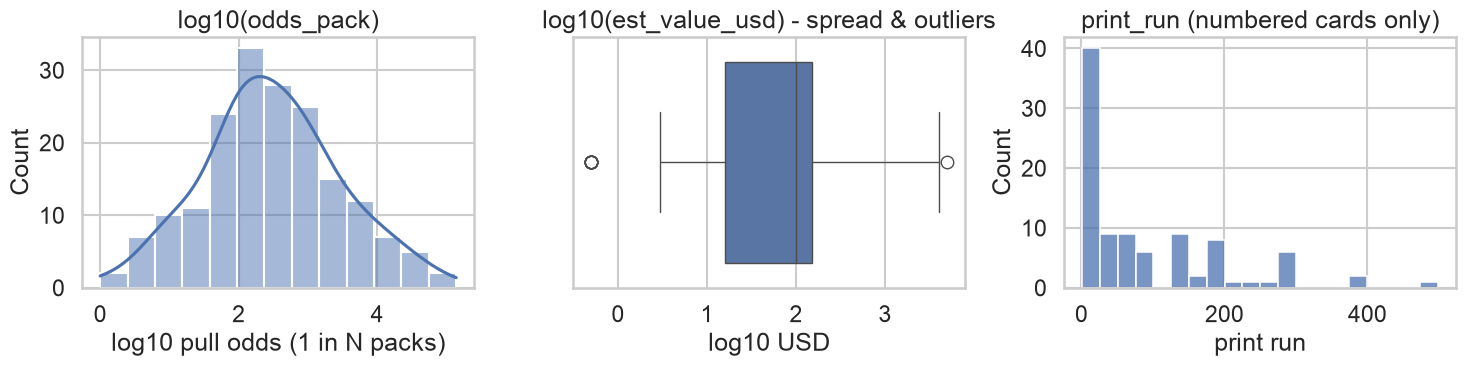

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(np.log10(df["odds_pack"].dropna()), kde=True, ax=ax[0])
ax[0].set_title("log10(odds_pack)"); ax[0].set_xlabel("log10 pull odds (1 in N packs)")

sns.boxplot(x=np.log10(df["est_value_usd"]), ax=ax[1])
ax[1].set_title("log10(est_value_usd) - spread & outliers"); ax[1].set_xlabel("log10 USD")

sns.histplot(df["print_run"].dropna(), bins=20, ax=ax[2])
ax[2].set_title("print_run (numbered cards only)"); ax[2].set_xlabel("print run")

plt.tight_layout(); plt.show()

Raw `odds_pack` is a single spike near zero with a 139,000-long tail; `log10` makes
it roughly symmetric (same for `est_value_usd`). `print_run` clusters at the round
marketing numbers (/5, /10, /25, /99, ...).

## 4) Relationships

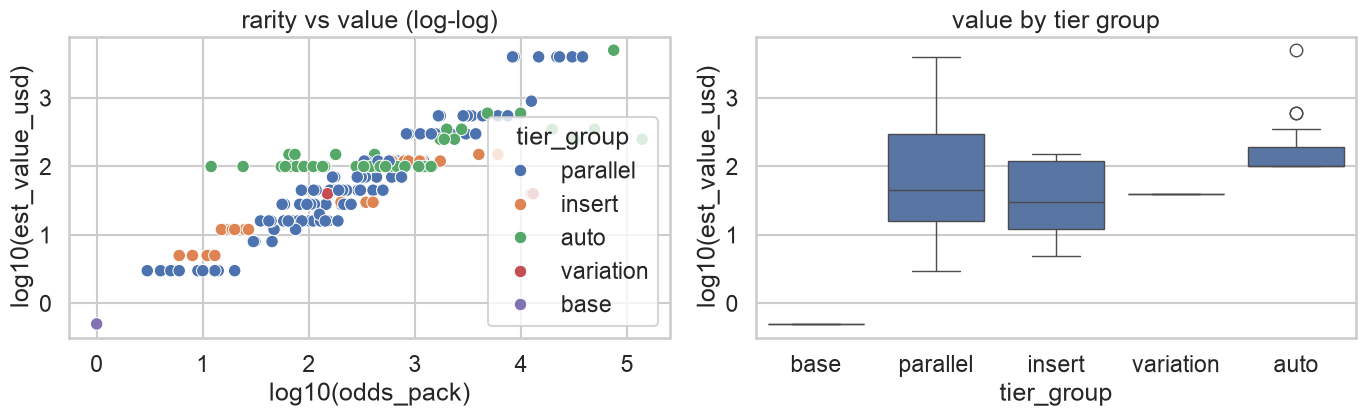

In [7]:
d = df.dropna(subset=["odds_pack"]).copy()
d["log_odds"] = np.log10(d["odds_pack"])
d["log_value"] = np.log10(d["est_value_usd"])
dv = df.assign(log_value=np.log10(df["est_value_usd"]))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

sns.scatterplot(data=d, x="log_odds", y="log_value", hue="tier_group", ax=ax[0])
ax[0].set_title("rarity vs value (log-log)")
ax[0].set_xlabel("log10(odds_pack)"); ax[0].set_ylabel("log10(est_value_usd)")

sns.boxplot(data=dv, x="tier_group", y="log_value",
            order=["base", "parallel", "insert", "variation", "auto"], ax=ax[1])
ax[1].set_title("value by tier group"); ax[1].set_ylabel("log10(est_value_usd)")

plt.tight_layout(); plt.show()

Rarer tiers are worth more, roughly linearly on the log-log scale — so a value model
should use `log10` on both. Autos and 1/1 variations sit above parallels/inserts at the
same rarity, so `tier_group` adds signal beyond odds.

## 4b) Over time

              n_tiers  mean_value  median_odds
release_date                                  
2025-12-18         37  227.310811        258.5
2026-04-22         31  408.693548        623.5
2026-04-29         29  227.603448        332.0
2026-05-14         27  262.611111        102.5
2026-05-28         29  264.224138        185.0
2026-08-06         41  324.573171        306.0 

distinct release dates: 6
gaps between releases (days): [125, 7, 15, 14, 70]


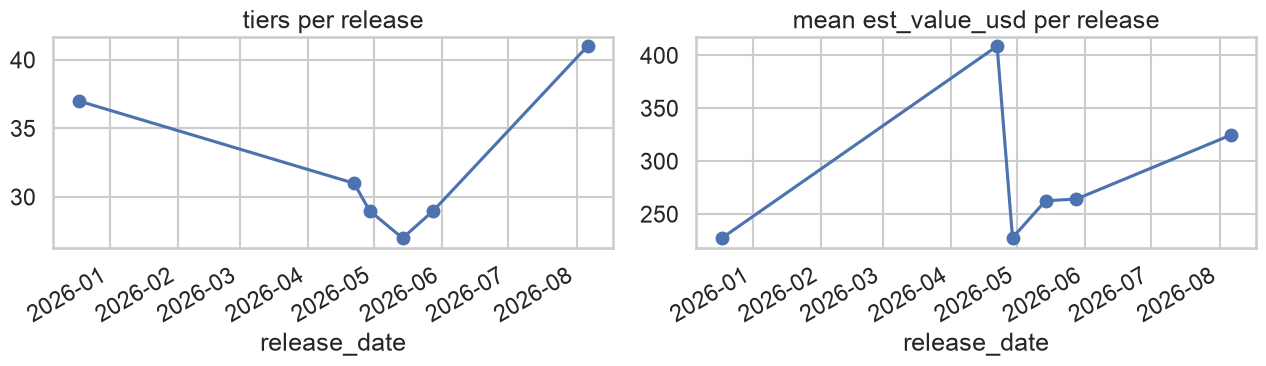

In [8]:
by_release = (df.groupby("release_date")
                .agg(n_tiers=("tier_name", "size"),
                     mean_value=("est_value_usd", "mean"),
                     median_odds=("odds_pack", "median")))
print(by_release, "\n")

dates = df["release_date"].drop_duplicates().sort_values()
print("distinct release dates:", len(dates))
print("gaps between releases (days):", dates.diff().dropna().dt.days.tolist())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
by_release["n_tiers"].plot(marker="o", ax=ax[0], title="tiers per release")
by_release["mean_value"].plot(marker="o", ax=ax[1], title="mean est_value_usd per release")
for a in ax:
    a.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

**Time-axis read.** No per-row timestamp — only each product's `release_date`
(6 dates, 2025-12-18 to 2026-08-06, uneven gaps `[125, 7, 15, 14, 70]` days).
`mean_value` and tier counts move with no trend and no cycle; at n = 6 that is not
seasonality, and there is no within-product ordering.

- *Stage 09:* lag / rolling features have no row axis to run along.
- *Stage 10b:* a chronological split is meaningless at 6 points — the task is
  classification / regression on tier attributes, not forecasting.

## 5) (Optional) Correlation matrix

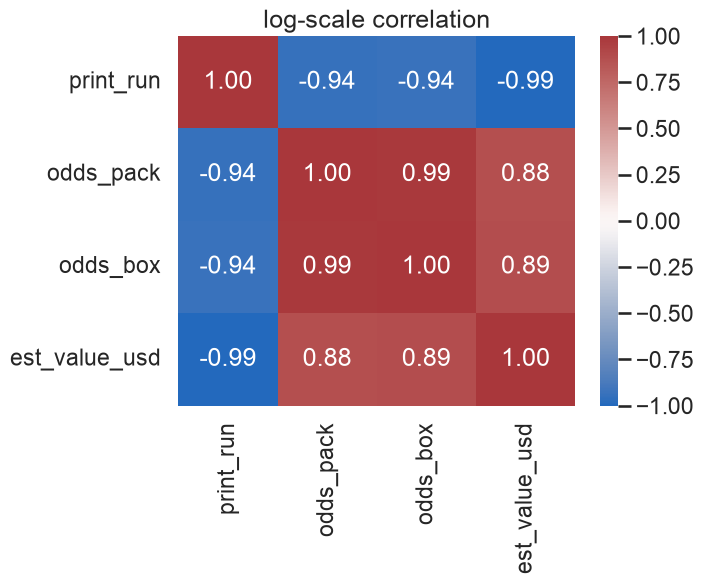

,print_run,odds_pack,odds_box,est_value_usd
print_run,1.000000,-0.941264,-0.935517,-0.994961
odds_pack,-0.941264,1.000000,0.990027,0.881003
odds_box,-0.935517,0.990027,1.000000,0.888781
est_value_usd,-0.994961,0.881003,0.888781,1.000000


In [9]:
corr = df[["print_run", "odds_pack", "odds_box", "est_value_usd"]].apply(np.log10).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1)
plt.title("log-scale correlation"); plt.show()
corr

`odds_pack` and `odds_box` are near-collinear on the log scale (both measure rarity)
— keep one. `est_value_usd` correlates ~0.8 with rarity: the relationship the value model
will use. `print_run` adds little beyond `odds_pack`.

## 5b) Reusable helper — `src/eda.py`

In [10]:
from src.eda import eda_summary, flag_columns

s = eda_summary(df)
print("shape:", s["shape"])
print("missing:", {k: v for k, v in s["missing"].items() if v})
print("flags :", flag_columns(df))
s["numeric_profile"]

shape: (194, 15)
missing: {'print_run': 99, 'odds_pack': 13, 'odds_box': 13, 'source_note': 174}
flags : {'box_format': 'one value = 100%', 'print_run': '51% missing', 'is_ssp': 'one value = 96%', 'value_basis': 'one value = 100%', 'source_note': '90% missing'}


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
print_run,95.0,96.105263,106.471300,1.00,10.00,50.00,150.00,499.00,1.362879,1.640604
odds_pack,181.0,3519.198895,13156.920371,1.00,76.00,286.00,1209.00,138789.00,7.416351,65.578591
odds_box,181.0,189.061050,668.443559,0.05,3.95,16.65,71.38,6939.45,7.093851,60.980879
est_value_usd,194.0,287.324742,815.751158,0.50,16.00,100.00,150.00,5000.00,4.414497,18.452395


## 6) Insights & Assumptions

### Top 3 insights
1. **Heavy right skew on the rarity / value columns** (`odds_pack` skew ~7.4,
   `est_value_usd` ~4.4, `odds_box` ~7.1). Every model needs `log10`; the log-log
   rarity/value scatter is roughly linear, the raw one is not.
2. **`print_run` is 51% NaN, but structurally** — NaN = an unnumbered card, already
   encoded by `is_numbered`. Not missing data to impute.
3. **Dead columns.** `box_format` / `value_basis` single-valued; `source_note` 90% NaN;
   `odds_pack` / `odds_box` near-collinear. And `est_value_usd` is a placeholder ladder,
   not real comps.

### Assumptions & risks
- Relationships here describe the `rough_estimate_v0` ladder, not market prices.
- `tier_group` is imbalanced — rare groups (variation 2%) will be noisy.
- No usable time axis (§4b): rules out lag / rolling features and a chronological split.

### Next steps before modelling (Stage 09)
- `log10` `odds_pack`, `odds_box`, `est_value_usd`; keep `odds_pack` over `odds_box`.
- One-hot `tier_group`; keep `is_numbered` / `is_autograph` / `is_ssp` as-is.
- Drop `box_format`, `value_basis`, `source_note`; treat structural NaN as a category.